<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/GPU_Accelerated_Golden_Section_Search_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

# Benchmarking Vectorized Golden Section Search (GSS) on CPU and GPU

### 1. Scientific Primer on the Golden Section Search
The **Golden Section Search** (**GSS**) is a robust numerical optimization technique employed to identify the extremum of a strictly unimodal function within a specified interval. Unlike gradient-based methods, which require the calculation of derivatives, GSS relies exclusively on function evaluations. The algorithm is predicated upon the **Golden Ratio**, denoted as $\varphi$, which is mathematically defined as:

$$\varphi = \frac{1 + \sqrt{5}}{2} \approx 1.6180339887$$

By selecting interior evaluation points based on the inverse of this ratio ($1/\varphi$), the algorithm ensures that in each subsequent iteration, one of the previously calculated points can be recycled. This leads to a consistent reduction of the search bracket, specifically narrowing the interval by a factor of approximately **0.618** per step.

### 2. Architectural Considerations: CPU vs. GPU
The provided implementation contrasts the execution performance of two distinct hardware architectures:
* **Central Processing Unit** (**CPU**): Utilizing **NumPy**, which is optimized for sequential or lightly threaded numerical operations.
* **Graphics Processing Unit** (**GPU**): Utilizing **CuPy**, a library that implements **Compute Unified Device Architecture** (**CUDA**) to perform high-throughput, **Single Instruction Multiple Data** (**SIMD**) parallel processing.

While a single GSS is inherently sequential (the next step depends on the current result), we utilize a **batched** approach. By optimizing $1,000,000$ independent functions simultaneously, we saturate the GPU's thousands of cores, effectively hiding the latency of individual operations through massive parallelism.

---

### 3. Parameter Definitions (Control Knobs)
The following table delineates the primary variables used to govern the simulation and optimization constraints:

| Parameter | Type | Description |
| :--- | :--- | :--- |
| `NUM_PROBLEMS` | `int` | The total count of independent functions optimized concurrently. |
| `TOLERANCE` | `float` | The convergence threshold; the search terminates when the interval width is below this value. |
| `MAX_ITERATIONS` | `int` | The computational ceiling for the number of interval reductions. |
| `LOWER_BOUND` | `float` | The starting inferior boundary ($a$) for the search space. |
| `UPPER_BOUND` | `float` | The starting superior boundary ($b$) for the search space. |

---

### 4. Code Logic and Vectorization Strategy

#### A. The Target Function
The `evaluate_target_function` utilizes a quadratic form: $f(x) = (x - \text{shift})^2 + 2.5$. By applying unique `shifts` to each of the million problems, we ensure the GPU is not simply calculating the same value repeatedly, but is instead managing a diverse data set across its memory.

#### B. The Vectorized Loop
The core of the `execute_batched_gss` function avoids traditional Python `if/else` branching, which would be catastrophically slow on a GPU. Instead, it employs `xp.where` (a ternary-like operator).



1.  **Interval Initialization**: The initial points $c$ and $d$ are calculated using the inverse golden ratio ($1/\varphi$).
2.  **Point Recycling**: Depending on whether $f(c) < f(d)$, the algorithm updates either the lower or upper bound. The implementation is "branchless" in design, meaning the same mathematical operations are applied to the entire array simultaneously.
3.  **Synchronization**: The command `cp.cuda.Stream.null.synchronize()` is invoked. This is a critical step in GPU benchmarking, ensuring that the CPU timer does not record a "completion" time until the GPU has actually finished all asynchronous kernel executions.

#### C. Performance Visualization
The script concludes by generating a high-resolution bar chart (rendered at **250 DPI**). This visualization provides an immediate empirical comparison of the total execution time (measured in seconds) between the **NumPy** and **CuPy** backends.

---

### Summary
The implementation demonstrates that while the **Golden Section Search** (**GSS**) is a sequential algorithm, it can be extraordinarily accelerated through vectorization. By treating a million independent optimization problems as a single multi-dimensional array, **CuPy** leverages the **GPU**'s parallel architecture to outperform the **CPU** by orders of magnitude.

This script provides a framework to prove that GPU acceleration is highly effective for GSS when the problem is scaled to a large batch of independent functions.

Using Python 3.12.13 environment at: /usr
Checked 3 packages in 176ms


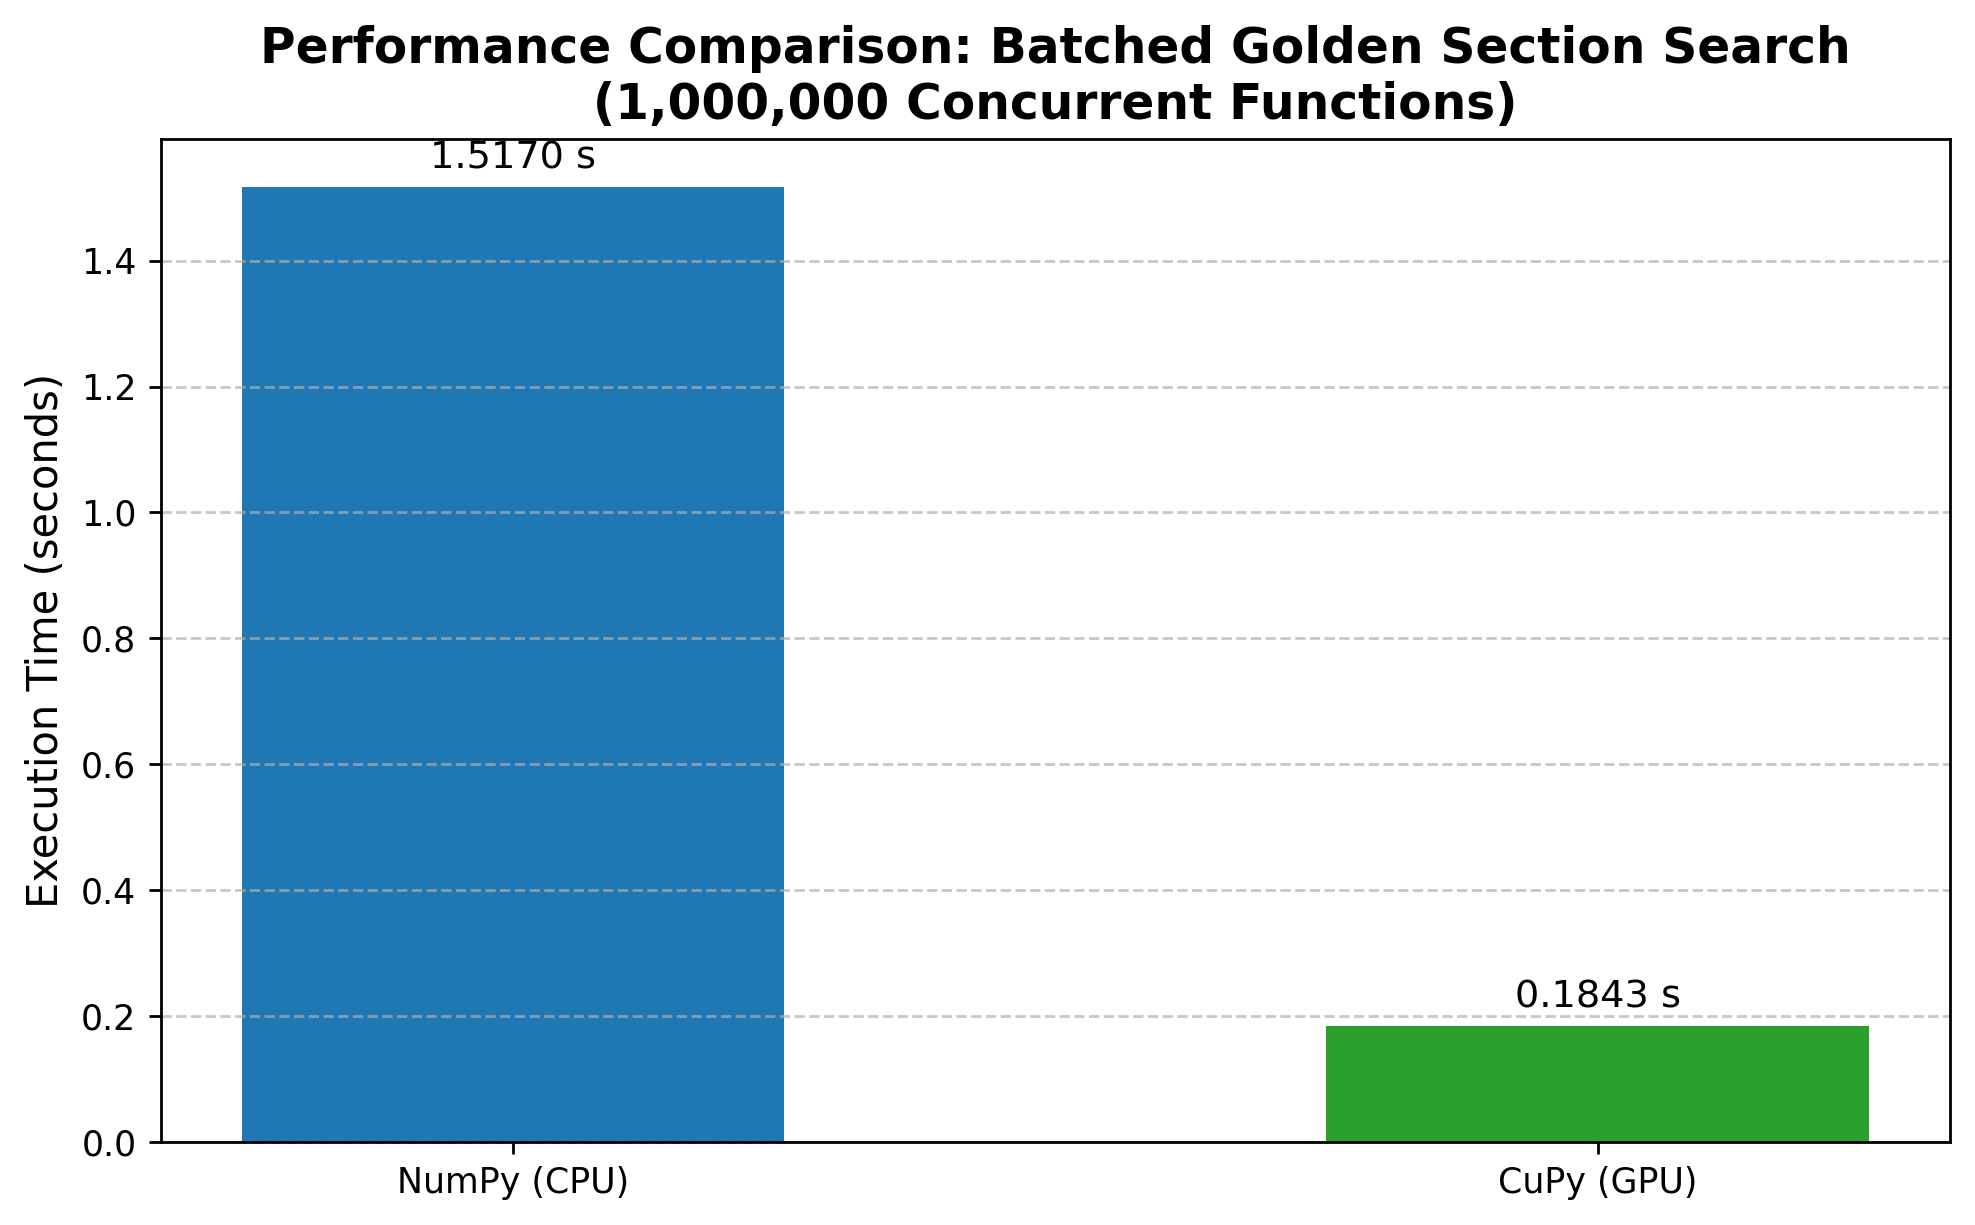

In [1]:
!uv pip install cupy-cuda12x numpy matplotlib
# Alternatively, using standard pip:
# !pip install cupy-cuda12x numpy matplotlib

import time
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
from typing import Tuple, Any

# ==========================================
# CONTROL KNOBS
# ==========================================
NUM_PROBLEMS: int = 1_000_000    # Total number of concurrent functions to optimize
TOLERANCE: float = 1e-5          # Convergence tolerance for interval width
MAX_ITERATIONS: int = 60         # Maximum allowable iterations
LOWER_BOUND: float = -10.0       # Initial universal lower bound (a)
UPPER_BOUND: float = 10.0        # Initial universal upper bound (b)
# ==========================================

# Enforce high-resolution plotting internally
plt.rcParams['figure.dpi'] = 250

def evaluate_target_function(x: Any, shifts: Any) -> Any:
    """
    Evaluate a batched array of strictly unimodal quadratic functions.

    Args:
        x (Any): The array of evaluation points (NumPy or CuPy array).
        shifts (Any): The array of phase shifts determining each function's minimum.

    Returns:
        Any: The evaluated function values.
    """
    return (x - shifts)**2 + 2.5

def execute_batched_gss(xp: Any, num_problems: int, tol: float, max_iter: int, lower: float, upper: float) -> Tuple[float, Any]:
    """
    Perform a highly vectorized Golden Section Search across multiple independent problems.

    Args:
        xp (Any): The array processing library to utilize (np for CPU, cp for GPU).
        num_problems (int): The quantity of independent functions to optimize.
        tol (float): The threshold for interval convergence.
        max_iter (int): The ceiling on total iterations.
        lower (float): The starting lower bound constraint.
        upper (float): The starting upper bound constraint.

    Returns:
        Tuple[float, Any]: The elapsed execution time and the final estimated minima array.
    """
    # Define the golden ratio mathematically
    phi: float = (1.0 + xp.sqrt(5.0)) / 2.0
    inv_phi: float = 1.0 / phi

    # Generate random phase shifts to ensure each problem represents a unique target minimum
    xp.random.seed(42)
    shifts = xp.random.uniform(lower + 2.0, upper - 2.0, num_problems)

    # Initialize boundary arrays
    a = xp.full(num_problems, lower, dtype=xp.float32)
    b = xp.full(num_problems, upper, dtype=xp.float32)

    # Calculate initial interior evaluation points
    c = b - (b - a) * inv_phi
    d = a + (b - a) * inv_phi

    fc = evaluate_target_function(c, shifts)
    fd = evaluate_target_function(d, shifts)

    # Synchronize GPU to ensure accurate timing measurement (null operation for CPU)
    if xp == cp:
        cp.cuda.Stream.null.synchronize()

    start_time: float = time.perf_counter()

    for _ in range(max_iter):
        # Assess universal convergence across all problems
        if xp.max(b - a) < tol:
            break

        # Determine the logical condition for interval replacement
        condition = fc < fd

        # Conditionally update the exterior bounds
        b_new = xp.where(condition, d, b)
        a_new = xp.where(condition, a, c)

        # Conditionally recycle the interior points
        d_new = xp.where(condition, c, a_new + (b_new - a_new) * inv_phi)
        c_new = xp.where(condition, b_new - (b_new - a_new) * inv_phi, d)

        # Conditionally recycle the previously computed function values
        fd_new = xp.where(condition, fc, evaluate_target_function(d_new, shifts))
        fc_new = xp.where(condition, evaluate_target_function(c_new, shifts), fd)

        # Apply the updated states
        a, b, c, d = a_new, b_new, c_new, d_new
        fc, fd = fc_new, fd_new

    # Synchronize GPU to finalize timing
    if xp == cp:
        cp.cuda.Stream.null.synchronize()

    execution_time: float = time.perf_counter() - start_time

    # Return the midpoint of the final converged interval
    final_minima = (a + b) / 2.0

    return execution_time, final_minima

# Execute standard CPU benchmarking
cpu_time, cpu_results = execute_batched_gss(np, NUM_PROBLEMS, TOLERANCE, MAX_ITERATIONS, LOWER_BOUND, UPPER_BOUND)

# Execute accelerated GPU benchmarking (an initial warmup run is recommended for accurate CuPy profiling)
_, _ = execute_batched_gss(cp, 100, TOLERANCE, MAX_ITERATIONS, LOWER_BOUND, UPPER_BOUND)
gpu_time, gpu_results = execute_batched_gss(cp, NUM_PROBLEMS, TOLERANCE, MAX_ITERATIONS, LOWER_BOUND, UPPER_BOUND)

# Construct a formal comparative visualization
fig, ax = plt.subplots(figsize=(8, 5))
architectures = ['NumPy (CPU)', 'CuPy (GPU)']
times = [cpu_time, gpu_time]
colors = ['#1f77b4', '#2ca02c']

bars = ax.bar(architectures, times, color=colors, width=0.5)

ax.set_ylabel('Execution Time (seconds)', fontsize=12)
ax.set_title(f'Performance Comparison: Batched Golden Section Search\n({NUM_PROBLEMS:,} Concurrent Functions)', fontsize=14, fontweight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Append explicit time labels above the visualized bars
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.4f} s',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=11)

# Render the plot interactively
plt.tight_layout()
plt.show()